In [ ]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import myfunction as mf
import myrfecv as mr
path_data_raw = "C:/Users/dell/OneDrive/file/"
path_country_nc = "C:/Users/dell/OneDrive/file/nc"
path_one_spdb = 'C:/Users/dell/OneDrive/file/SPDB/'
drive_letter = 'E:'

path_pre = drive_letter + "/wyy/code_project/running_outcome/final_data/SPDB/part0_treat/pretreatment/"
path_match = drive_letter + "/wyy/code_project/running_outcome/final_data/SPDB/part0_treat/match/"


path_2_preanalysis_data = drive_letter + "/wyy/code_project/running_outcome/final_data/SPDB/part2_analysis/preanalysis/"

path_3_forecast_fig = drive_letter + "/wyy/code_project/running_outcome/final_data/SPDB/part3_forecast/fig/"

path_temp = drive_letter + "/wyy/code_project/running_outcome/final_data/SPDB/temp/"

meta_name = "meta_data.csv"

list_color = ["#ee877c", "#8bd0e3", "#6abeae", "#808eaf", "#f7bba8", "#acb4cc", "#b5e0d5", "#e86462", "#a89687"]

### 函数准备

In [ ]:

from factor_analyzer import FactorAnalyzer
from openpyxl import Workbook
from openpyxl.styles import PatternFill
from openpyxl.utils.dataframe import dataframe_to_rows
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

def forward_select_vif(df_features_raw, one_var, max_vif=10):
    selected_vars = [one_var]
    remaining_vars = [var for var in df_features_raw.columns if var != one_var]
    vif_data = pd.DataFrame(columns=['variables', 'VIF'])

    while remaining_vars:
        temp_vif_data = pd.DataFrame(columns=['variables', 'VIF'])
        for var in remaining_vars:
            temp_df = df_features_raw[selected_vars + [var]]
            temp_vif = [variance_inflation_factor(temp_df.values, i)
                        for i in range(temp_df.shape[1])]

            if all(vif < max_vif for vif in temp_vif[:-1]):  # 排除添加的当前变量的VIF

                new_row = pd.DataFrame({'variables': [var], 'VIF': [temp_vif[-1]]})
                temp_vif_data = pd.concat([temp_vif_data, new_row], ignore_index=True)

        temp_vif_data['VIF'] = pd.to_numeric(temp_vif_data['VIF'], errors='coerce')

        temp_vif_data = temp_vif_data[temp_vif_data['VIF'] < max_vif]
        if temp_vif_data.empty:
            break

        next_var = temp_vif_data.loc[temp_vif_data['VIF'].idxmin(), 'variables']
        selected_vars.append(next_var)
        remaining_vars.remove(next_var)

    final_df = df_features_raw[selected_vars]
    vif_data['variables'] = final_df.columns
    vif_data['VIF'] = [variance_inflation_factor(final_df.values, i) 
                       for i in range(final_df.shape[1])]

    return vif_data


def count_vif(df_features_raw, max_vif=10):
    """迭代计算输入的dataframe VIF 每次迭代去除VIF最大的变量 直到所有变量的VIF小于10
        返回一个dataframe 里面包含两列 variables VIF"""
    vif_data = pd.DataFrame()
    vif_data["variables"] = df_features_raw.columns

    while True:

        vif_data["VIF"] = [variance_inflation_factor(df_features_raw.values, i) 
                        for i in range(len(df_features_raw.columns))]

        if vif_data['VIF'].max() > max_vif:
            max_vif_feature = vif_data.loc[vif_data['VIF'].idxmax(), 'variables']
            df_features_raw = df_features_raw.drop(max_vif_feature, axis=1)
            vif_data = vif_data[vif_data['variables'] != max_vif_feature]
            print('Remove var:',max_vif_feature)
        else:
            break
    print(vif_data.shape)
    return vif_data


def count_fa(df, level_name, flash_excel="NO", feature_type="standardization"):
    """根据df的数据 使用因子分析 识别潜在变量 level_name命名输出文件 flash_excel等于NO时不更改excel
        excel是给人看的 里面会标注重要变量  feature_type命名输出文件
        这个函数直接输出文件 返回的只有okk"""
    df_meta = pd.read_csv(path_data_raw + meta_name, encoding="utf-8")

    var_to_meaning = dict(zip(df_meta['var_name'], df_meta['meaning']))
    fa = FactorAnalyzer(rotation='varimax')
    fa.fit(df)
    loadings = fa.loadings_
    eigen_values, vectors = fa.get_eigenvalues()
    num_factors = sum(eigen_values > 1)
    print("num_factors:", num_factors)
    adjusted_eigen_values = list(eigen_values[:num_factors])#  + [None] * (len(loadings[0]) - num_factors)
    fa = FactorAnalyzer(n_factors=num_factors, rotation='varimax')
    fa.fit(df)
    loadings = fa.loadings_
    explained_variance = fa.get_factor_variance()
    explained_variance_df = pd.DataFrame(explained_variance, 
                                        index=['SS Loadings','Proportion Var','Cumulative Var'], 
                                        columns=['Factor'+str(i+1) for i in range(num_factors)])
    explained_variance_df.loc['Eigenvalues'] = adjusted_eigen_values
    loadings_df = pd.DataFrame(loadings, index=df.columns, 
                            columns=['Factor'+str(i+1) for i in range(num_factors)])
    loadings_df = pd.concat([explained_variance_df, loadings_df])
    scores = fa.transform(df)
    loadings_df['Meaning'] = loadings_df.index.map(var_to_meaning)
    loadings_df = loadings_df.reset_index().rename(columns={'index': 'vars'})
    cols = loadings_df.columns.tolist()
    cols.insert(0, cols.pop(cols.index('Meaning')))
    loadings_df = loadings_df.reindex(columns=cols)

    scores = fa.transform(df)

    scores_df = pd.DataFrame(scores, columns=['Factor'+str(i+1) for i in range(num_factors)])
    loadings_df.to_csv(path_temp + 'fa_loadings_' + feature_type+ '_' + level_name + mark_num +'.csv',index=False)
    scores_df.to_csv(path_2_preanalysis_data + 'fa_scores_' + feature_type+ '_' + level_name + mark_num +'.csv',index=False)
    if flash_excel == "NO":
        print("pass")
        pass
    else:
        print("flash excel")
        df_e = pd.read_csv(path_temp + 'fa_loadings_' + feature_type+ '_' + level_name + mark_num +'.csv')

        cols = ['Factor'+str(i+1) for i in range(num_factors)]

        color_fill = PatternFill(start_color="90EE90",
                                    end_color="90EE90",
                                    fill_type="solid")
        wb = Workbook()
        ws = wb.active

        for r in dataframe_to_rows(df_e, index=False, header=True):
            ws.append(r)

        cols_index = [df_e.columns.get_loc(c) + 1 for c in cols]
        for row in ws.iter_rows(min_row=2, min_col=min(cols_index), max_col=max(cols_index), max_row=len(df_e)+1):
            values = [cell.value for cell in row]
            max_abs_value = max(values, key=abs)
            if abs(max_abs_value) >= 0.3:

                original_max_value = max(values, key=lambda x: abs(x) == abs(max_abs_value))
                for cell in row:
                    if cell.value == original_max_value:
                        cell.fill = color_fill
        wb.save(path_2_preanalysis_data + 'fa_' + feature_type+ '_' + level_name + mark_num +'.xlsx')
    return num_factors


def print_equation(df, str_var='NO'):
    """快速生成model中潜在变量的公式 方便写代码
        这个函数直接输出文本 返回的只有okk"""
    df = df.iloc[4:]
    df = df.drop("Meaning", axis=1)
    df.set_index('vars', inplace=True)
    dic_var = {col: [] for col in df.columns}

    for index, row in df.iterrows():
        max_val = row.abs().max()
        if max_val >= 0.3:
            max_col = row.abs().idxmax()
            dic_var[max_col].append(index)

    if str_var != 'NO':
        new_dic_var = {}
        for i, (key, value) in enumerate(dic_var.items()):
            new_key = f'{str_var}_{i}'
            new_dic_var[new_key] = value
        dic_var = new_dic_var

    for key, value in dic_var.items():
        str_value = ' + '.join(value)
        print(f'{key} =~ {str_value}')

    return "okk"



def count_variance(df_sem_data):
    """计算所有变量的方法  返回的是一个df"""
    print(df_sem_data.shape)
    mean = df_sem_data.mean()
    std_dev = df_sem_data.std()
    variance = df_sem_data.var()


    df_results = pd.DataFrame({
        'var': df_sem_data.columns,
        'mean': mean.values,
        'SD': std_dev.values,
        'variance': variance.values
    })


    min_variance = df_results["variance"].min()
    max_variance = df_results["variance"].max()
    print(min_variance, max_variance)
    print(max_variance/min_variance)

    return df_results


### lr

In [4]:
scoring = 'r2'
str_describe = 'lr'
df_lr_sem = pd.read_csv(path_match + "lr_match_treat_full.csv")
path_lr_rfecv_data = drive_letter + '/wyy/code_project/running_outcome/final_data/SPDB/part3_forecast/lr_forecast/'

df_lr_sem['year'] = (df_lr_sem['year'] - 2000) / (2020 - 2000)

fish_feature, fish_model = mr.get_best_model(path_lr_rfecv_data, str_describe)

X = df_lr_sem[fish_feature]
y = df_lr_sem['value']



LGBM


In [ ]:


from sklearn.ensemble import RandomForestRegressor
scoring = 'r2'
str_describe = 'lr'
df_lr_sem = pd.read_csv(path_match + "lr_match_treat_full.csv")
path_lr_rfecv_data = drive_letter + '/wyy/code_project/running_outcome/final_data/SPDB/part3_forecast/lr_forecast/'

df_lr_sem['year'] = (df_lr_sem['year'] - 2000) / (2020 - 2000)

selected_features_rf = pd.read_csv(path_lr_rfecv_data + str_describe + "_rfecv_features_RFcv.csv")
selected_features_rf = selected_features_rf[selected_features_rf["Rank"] == 1]["Feature"].values

best_params = pd.read_csv(path_lr_rfecv_data + 'ml_cv_best.csv')

rf_params = best_params[best_params["model"] == "RF"].iloc[0]

if rf_params["param_max_depth"] == 'None':
    param_max_depth_rf = None
else:
    param_max_depth_rf = int(rf_params["param_max_depth"])
model_fish = RandomForestRegressor(
    max_depth=param_max_depth_rf,
    min_samples_leaf=int(rf_params["param_min_samples_leaf"]),
    min_samples_split=int(rf_params["param_min_samples_split"]),
    n_estimators=int(rf_params["param_n_estimators"])
)
X = df_lr_sem[selected_features_rf]
y = df_lr_sem['value']

In [ ]:

import shap
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


model_fish.fit(X, y)

try:
    explainer_fish = shap.TreeExplainer(model_fish)
    shap_values_fish = explainer_fish(X)


    shap_save_path_fish = path_3_forecast_fig + 'shap_values_lr.pkl'
    with open(shap_save_path_fish, 'wb') as f:
        pickle.dump(shap_values_fish, f)

    print("SHAP values calculated and saved successfully.")
except Exception as e:
    print(f"Error calculating or saving SHAP values: {e}")



SHAP values calculated and saved successfully.


SHAP values loaded successfully.


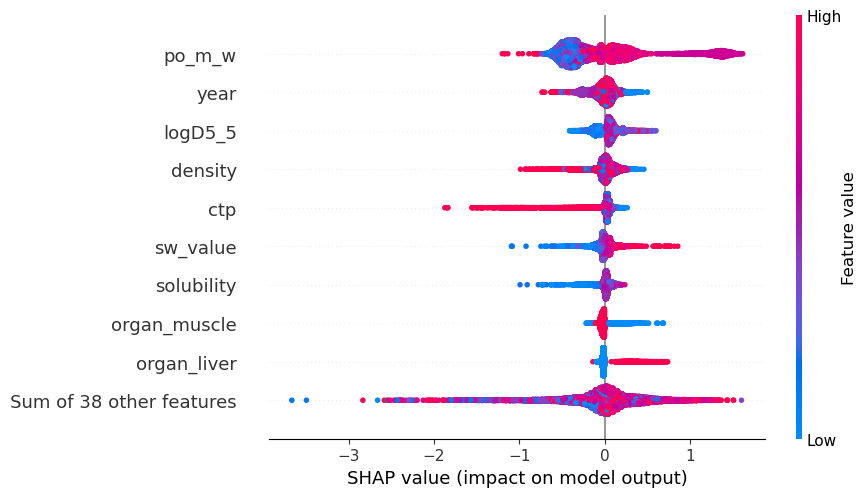

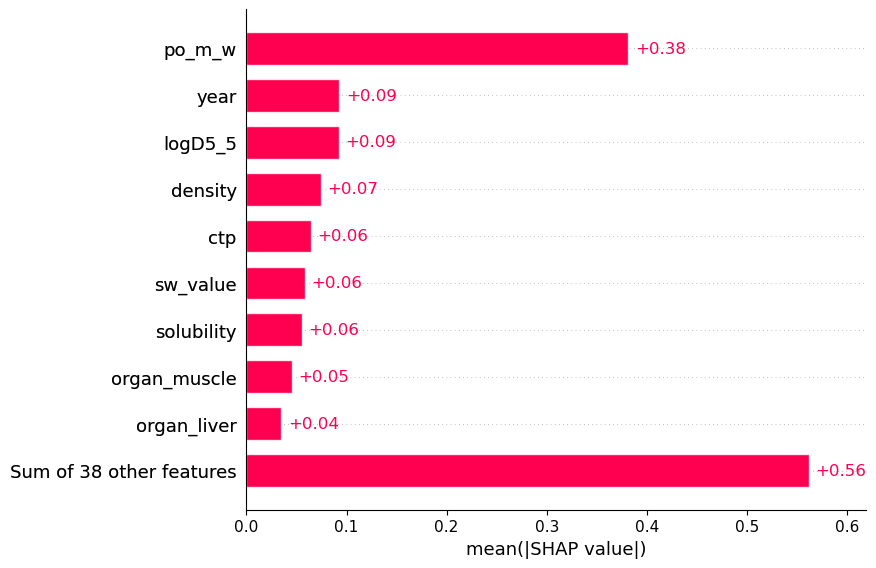

The figure layout has changed to tight
The figure layout has changed to tight


In [ ]:

import shap
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
shap_save_path_fish = path_3_forecast_fig + 'shap_values_lr.pkl'
try:
    with open(shap_save_path_fish, 'rb') as f:
        loaded_shap_values_fish = pickle.load(f)
    print("SHAP values loaded successfully.")
except Exception as e:
    print(f"Error loading SHAP values: {e}")
    loaded_shap_values_fish = None

if loaded_shap_values_fish is not None:

    shap.plots.beeswarm(loaded_shap_values_fish)
    plt.title("SHAP Beeswarm Plot")
    plt.tight_layout()

    plt.close()


    shap.plots.bar(loaded_shap_values_fish)
    plt.title("SHAP Bar Plot")
    plt.tight_layout()

    plt.close()


    shap.summary_plot(loaded_shap_values_fish, X, plot_type="bar", show=False, color='#7d84a8')
    plt.title("SHAP Summary Bar Plot")


    ax = plt.gca()
    for p in ax.patches:
        width = p.get_width()
        ax.text(width, p.get_y() + p.get_height()/2, f'{width:.3f}', 
                ha='left', va='center')

    plt.tight_layout()
    plt.savefig(path_3_forecast_fig + 'shap_lr_summary_bar_plot.svg', bbox_inches='tight')
    plt.close()



    colors = ['#FFFF00', '#FF0000']
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=n_bins)

    shap.summary_plot(loaded_shap_values_fish, X, plot_type="dot", show=False, cmap=cmap)
    plt.title("SHAP Summary Dot Plot")
    plt.tight_layout()
    plt.savefig(path_3_forecast_fig + 'shap_lr_summary_dot_plot.svg', bbox_inches='tight')
    plt.close()
else:
    print("Unable to create plots: SHAP values not loaded successfully.")

In [ ]:

import numpy as np
import matplotlib.colors as mcolors

feature_importance = np.abs(loaded_shap_values_fish.values).mean(0)
feature_importance_order = np.argsort(feature_importance)[::-1]


top_5_features = feature_importance_order[:6]


top_5_shap_values = loaded_shap_values_fish.values[:, top_5_features]
top_5_feature_names = X.columns[top_5_features]
top_5_X = X.iloc[:, top_5_features]


shap.summary_plot(top_5_shap_values, top_5_X, plot_type="bar", show=False, color='#7d84a8', feature_names=top_5_feature_names)
plt.title("SHAP Summary Bar Plot (Top 5 Features)")


ax = plt.gca()
for p in ax.patches:
    width = p.get_width()
    ax.text(width, p.get_y() + p.get_height()/2, f'{width:.3f}', 
            ha='left', va='center')

plt.tight_layout()
plt.savefig(path_3_forecast_fig + 'fig4_lr_bar_top6.svg', bbox_inches='tight')
plt.close()


colors = ['#FFFF00', '#FF0000']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=n_bins)

shap.summary_plot(top_5_shap_values, top_5_X, plot_type="dot", show=False, cmap=cmap, feature_names=top_5_feature_names, alpha=0.1, max_display=6)
plt.title("SHAP Summary Dot Plot (Top 5 Features)")
plt.tight_layout()
plt.savefig(path_3_forecast_fig + 'fig4_lr_dot_top6.svg', bbox_inches='tight')
plt.close()

The figure layout has changed to tight
The figure layout has changed to tight


### sw

In [7]:
scoring = 'r2'
str_describe = 'sw'
df_sw_sem = pd.read_csv(path_match + "sw_match_treat.csv")
path_sw_rfecv_data = drive_letter + '/wyy/code_project/running_outcome/final_data/SPDB/part3_forecast/sw_forecast/'

df_sw_sem['year'] = (df_sw_sem['year'] - 2000) / (2020 - 2000)

water_feature, water_model = mr.get_best_model(path_sw_rfecv_data, str_describe)

X2 = df_sw_sem[water_feature]
y2 = df_sw_sem['value']


LGBM


In [18]:
scoring = 'r2'
str_describe = 'sw'
df_sw_sem = pd.read_csv(path_match + "sw_match_treat.csv")
path_sw_rfecv_data = drive_letter + '/wyy/code_project/running_outcome/final_data/SPDB/part3_forecast/sw_forecast/'

df_sw_sem['year'] = (df_sw_sem['year'] - 2000) / (2020 - 2000)

selected_features_rf = pd.read_csv(path_sw_rfecv_data + str_describe + "_rfecv_features_RFcv.csv")
selected_features_rf = selected_features_rf[selected_features_rf["Rank"] == 1]["Feature"].values

best_params = pd.read_csv(path_sw_rfecv_data + 'ml_cv_best.csv')

rf_params = best_params[best_params["model"] == "RF"].iloc[0]

if rf_params["param_max_depth"] == 'None':
    param_max_depth_rf = None
else:
    param_max_depth_rf = int(rf_params["param_max_depth"])
model_sw = RandomForestRegressor(
    max_depth=param_max_depth_rf,
    min_samples_leaf=int(rf_params["param_min_samples_leaf"]),
    min_samples_split=int(rf_params["param_min_samples_split"]),
    n_estimators=int(rf_params["param_n_estimators"])
)

X2 = df_sw_sem[selected_features_rf]
y2 = df_sw_sem['value']


In [ ]:

import shap
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


model_sw.fit(X2, y2)


try:
    explainer_sw = shap.TreeExplainer(model_sw)
    shap_values_sw = explainer_sw(X2)


    shap_save_path_sw = path_3_forecast_fig + 'shap_values_sw.pkl'
    with open(shap_save_path_sw, 'wb') as f:
        pickle.dump(shap_values_sw, f)

    print("SHAP values calculated and saved successfully.")
except Exception as e:
    print(f"Error calculating or saving SHAP values: {e}")


SHAP values calculated and saved successfully.


SHAP values loaded successfully.


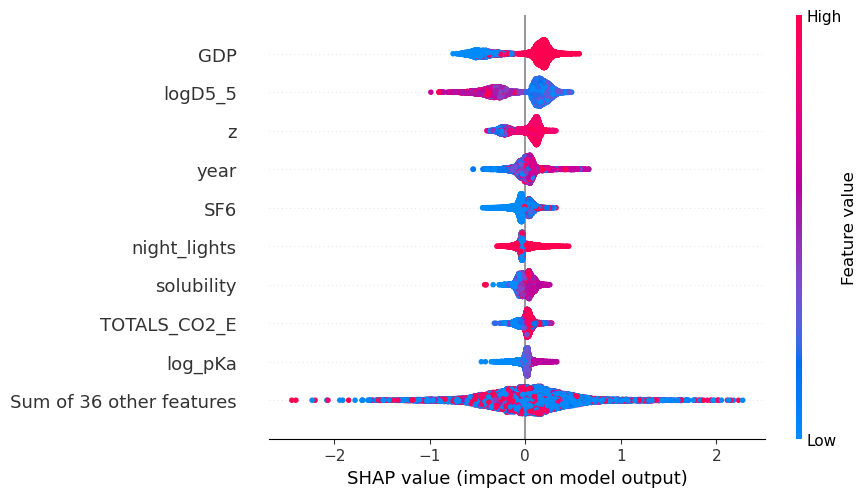

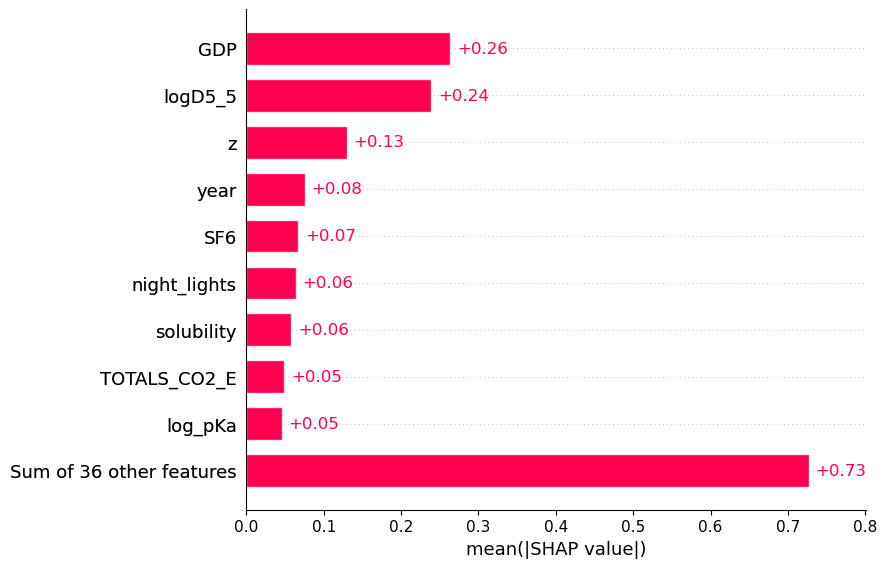

The figure layout has changed to tight
The figure layout has changed to tight


In [ ]:

import shap
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
shap_save_path_sw = path_3_forecast_fig + 'shap_values_sw.pkl'
try:
    with open(shap_save_path_sw, 'rb') as f:
        loaded_shap_values_sw = pickle.load(f)
    print("SHAP values loaded successfully.")
except Exception as e:
    print(f"Error loading SHAP values: {e}")
    loaded_shap_values_sw = None

if loaded_shap_values_sw is not None:

    shap.plots.beeswarm(loaded_shap_values_sw)
    plt.title("SHAP Beeswarm Plot")
    plt.tight_layout()

    plt.close()


    shap.plots.bar(loaded_shap_values_sw)
    plt.title("SHAP Bar Plot")
    plt.tight_layout()

    plt.close()


    shap.summary_plot(loaded_shap_values_sw, X2, plot_type="bar", show=False, color='#84aeb8')
    plt.title("SHAP Summary Bar Plot")


    ax = plt.gca()
    for p in ax.patches:
        width = p.get_width()
        ax.text(width, p.get_y() + p.get_height()/2, f'{width:.3f}', 
                ha='left', va='center')

    plt.tight_layout()
    plt.savefig(path_3_forecast_fig + 'shap_sw_summary_bar_plot.svg', bbox_inches='tight')
    plt.close()



    colors = ['#FFFF00', '#FF0000']
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=n_bins)

    shap.summary_plot(loaded_shap_values_sw, X2, plot_type="dot", show=False, cmap=cmap)
    plt.title("SHAP Summary Dot Plot")
    plt.tight_layout()
    plt.savefig(path_3_forecast_fig + 'shap_sw_summary_dot_plot.svg', bbox_inches='tight')
    plt.close()
else:
    print("Unable to create plots: SHAP values not loaded successfully.")

In [ ]:

import numpy as np
import matplotlib.colors as mcolors

feature_importance = np.abs(loaded_shap_values_sw.values).mean(0)
feature_importance_order = np.argsort(feature_importance)[::-1]


top_5_features = feature_importance_order[:5]


top_5_shap_values = loaded_shap_values_sw.values[:, top_5_features]
top_5_feature_names = X2.columns[top_5_features]
top_5_X2 = X2.iloc[:, top_5_features]


shap.summary_plot(top_5_shap_values, top_5_X2, plot_type="bar", show=False, color='#84aeb8', feature_names=top_5_feature_names)
plt.title("SHAP Summary Bar Plot (Top 5 Features)")

ax = plt.gca()
for p in ax.patches:
    width = p.get_width()
    ax.text(width, p.get_y() + p.get_height()/2, f'{width:.3f}', 
            ha='left', va='center')

plt.tight_layout()
plt.savefig(path_3_forecast_fig + 'fig4_sw_bar_top5.svg', bbox_inches='tight')
plt.close()


colors = ['#FFFF00', '#FF0000']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=n_bins)

shap.summary_plot(top_5_shap_values, top_5_X2, plot_type="dot", show=False, cmap=cmap, feature_names=top_5_feature_names, alpha=0.1)
plt.title("SHAP Summary Dot Plot (Top 5 Features)")
plt.tight_layout()
plt.savefig(path_3_forecast_fig + 'fig4_sw_dot_top5.svg', bbox_inches='tight')
plt.close()

The figure layout has changed to tight
The figure layout has changed to tight
